# Sentiment Analysis On Amazon Customer Review

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')
nltk.download('maxent_ne_chunker')
nltk.download('averaged_perceptron_tagger')

import sys
!{sys.executable} -m pip install svgling

nltk.download('vader_lexicon')

!pip install transformers

import sys
!{sys.executable} -m pip install transformers

import sys
!{sys.executable} -m pip install torch torchvision torchaudio

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/shwetatiwari/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/shwetatiwari/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/shwetatiwari/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /Users/shwetatiwari/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     /Users/shwetatiwari/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /Users/shwetatiwari/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloadi

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/shwetatiwari/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
df=pd.read_csv("/Users/shwetatiwari/Downloads/Reviews.csv")

In [3]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [4]:
df.shape

(568454, 10)

In [5]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [7]:
# Checking for missing data
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [8]:
# Handling missing data
df = df.dropna()

In [9]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [10]:
# Checking for duplicated data
df.duplicated().sum()

0

# EDA

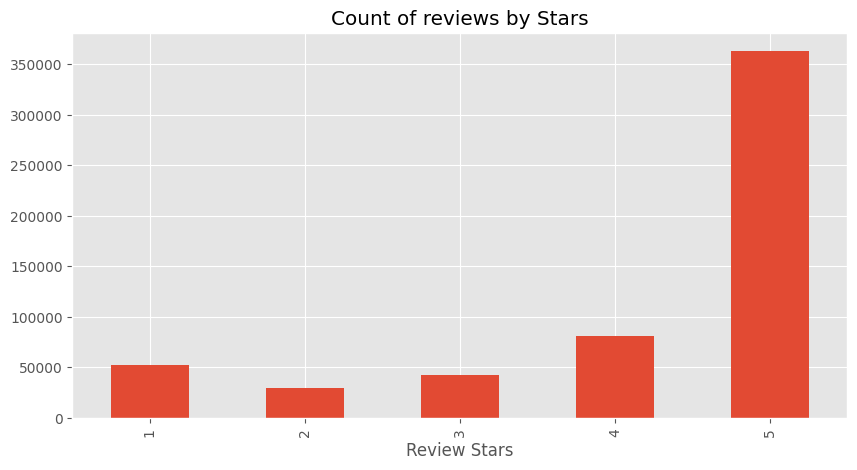

In [11]:
ax=df['Score'].value_counts().sort_index().plot(kind='bar',title='Count of reviews by Stars',figsize=(10,5))
ax.set_xlabel('Review Stars')
plt.show()

# NLTK

In [12]:
example=df['Text'].iloc[-1]
example

'I am very satisfied ,product is as advertised, I use it on cereal, with raw vinegar, and as a general sweetner.'

In [13]:
# Tokenizing the input text into words
tokens=nltk.word_tokenize(example)
tokens

['I',
 'am',
 'very',
 'satisfied',
 ',',
 'product',
 'is',
 'as',
 'advertised',
 ',',
 'I',
 'use',
 'it',
 'on',
 'cereal',
 ',',
 'with',
 'raw',
 'vinegar',
 ',',
 'and',
 'as',
 'a',
 'general',
 'sweetner',
 '.']

In [14]:
# Applying POS tagging on tokenized words 
tagged=nltk.pos_tag(tokens)
tagged

[('I', 'PRP'),
 ('am', 'VBP'),
 ('very', 'RB'),
 ('satisfied', 'JJ'),
 (',', ','),
 ('product', 'NN'),
 ('is', 'VBZ'),
 ('as', 'IN'),
 ('advertised', 'JJ'),
 (',', ','),
 ('I', 'PRP'),
 ('use', 'VBP'),
 ('it', 'PRP'),
 ('on', 'IN'),
 ('cereal', 'NN'),
 (',', ','),
 ('with', 'IN'),
 ('raw', 'JJ'),
 ('vinegar', 'NN'),
 (',', ','),
 ('and', 'CC'),
 ('as', 'IN'),
 ('a', 'DT'),
 ('general', 'JJ'),
 ('sweetner', 'NN'),
 ('.', '.')]

In [15]:
# Common POS Tags

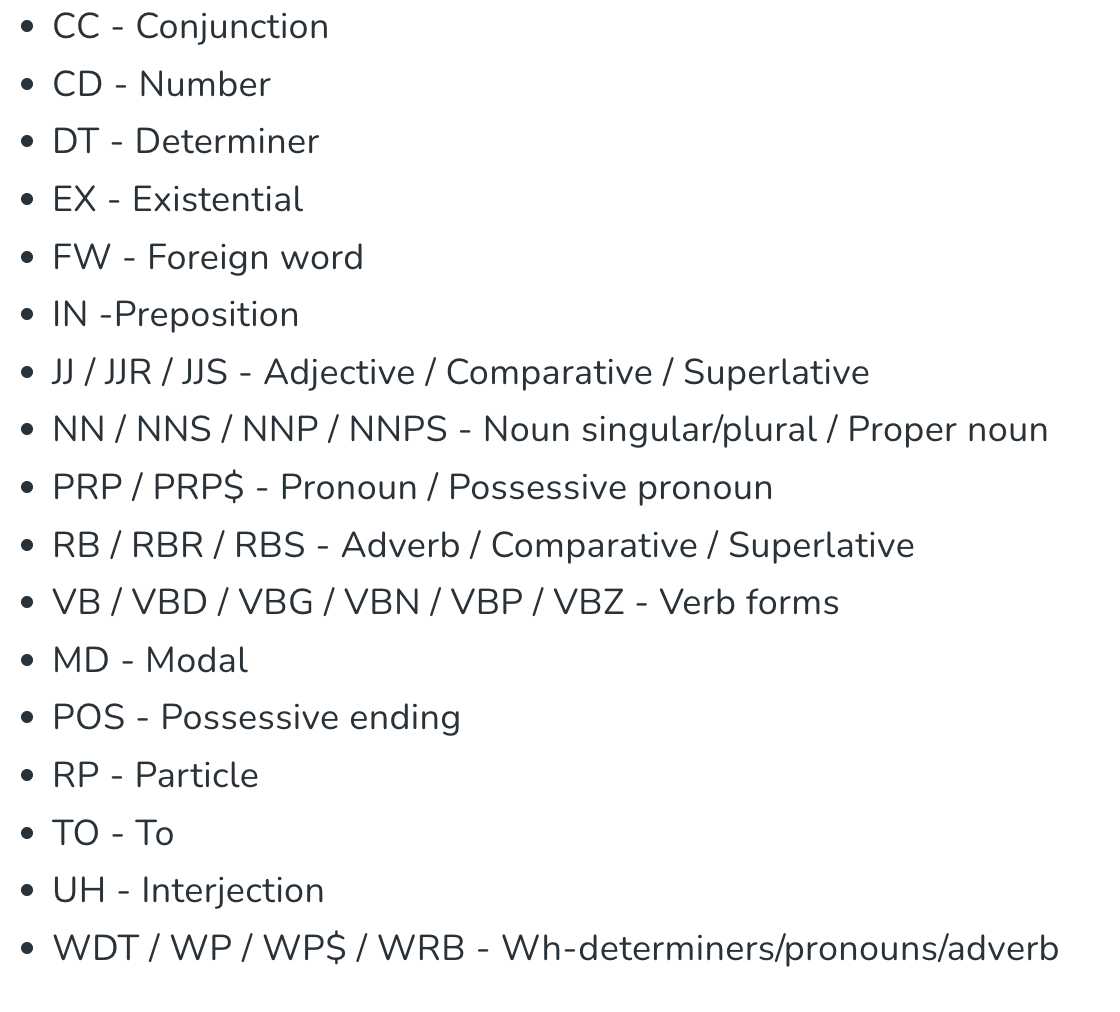

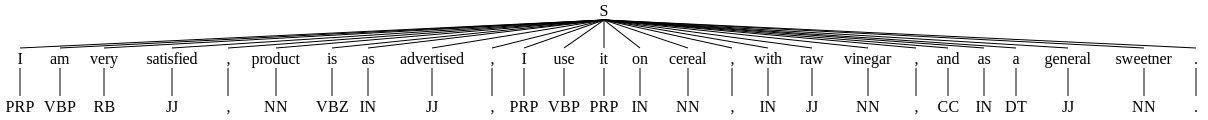

In [16]:
entities=nltk.chunk.ne_chunk(tagged)
entities

# VADER Sentiment Scoring

We will use NLTK's SentimentIntensityAnalyzer to get the neg/neu/pos scores of the text.

This uses a "bag of words" approach:
1. Stop words are removed
2. Each word is scored and combined to a total score.

In [17]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
sia=SentimentIntensityAnalyzer()

In [18]:
sia.polarity_scores('I am so happy today')

{'neg': 0.0, 'neu': 0.429, 'pos': 0.571, 'compound': 0.6115}

In [19]:
sia.polarity_scores('Shut the fuck up bitch!!!')

{'neg': 0.732, 'neu': 0.268, 'pos': 0.0, 'compound': -0.8472}

In [20]:
sia.polarity_scores(example)

{'neg': 0.0, 'neu': 0.846, 'pos': 0.154, 'compound': 0.4754}

In [21]:
# Running the polarity score on the entire dataset
res={}
for i,row in tqdm(df.iterrows(),total=len(df)):
    text=row['Text']
    myid=row['Id']
    res[myid]=sia.polarity_scores(text)

  0%|          | 0/568401 [00:00<?, ?it/s]

In [23]:
vaders=pd.DataFrame(res).T
vaders

,neg,neu,pos,compound
1,0.000,0.695,0.305,0.9441
2,0.138,0.862,0.000,-0.5664
3,0.091,0.754,0.155,0.8265
4,0.000,1.000,0.000,0.0000
5,0.000,0.552,0.448,0.9468
...,...,...,...,...
568450,0.072,0.600,0.327,0.8589
568451,0.190,0.697,0.114,-0.4848
568452,0.037,0.884,0.078,0.4352
568453,0.041,0.506,0.452,0.9717


In [24]:
vaders = vaders.reset_index().rename(columns={'index': 'Id'}) # Renaming the index to Id
vaders = vaders.merge(df, how='left', on='Id')  # Combining vaders to original df on the basis of Id which is common to both

In [25]:
vaders.head()

,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


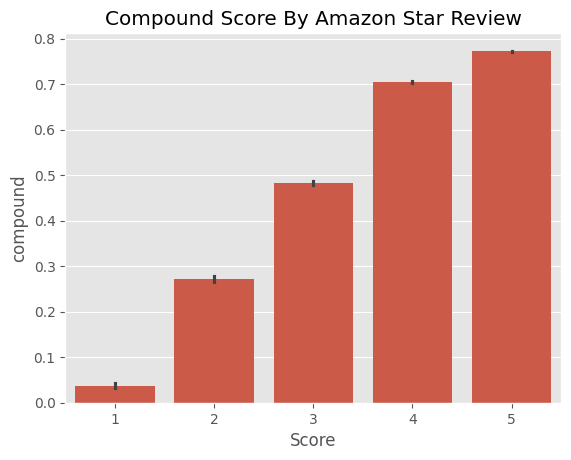

In [26]:
# Visualizing overall sentiment (compound score) for each Amazon star rating

ax=sns.barplot(data=vaders,x='Score',y='compound')
ax.set_title('Compound Score By Amazon Star Review')
plt.show()

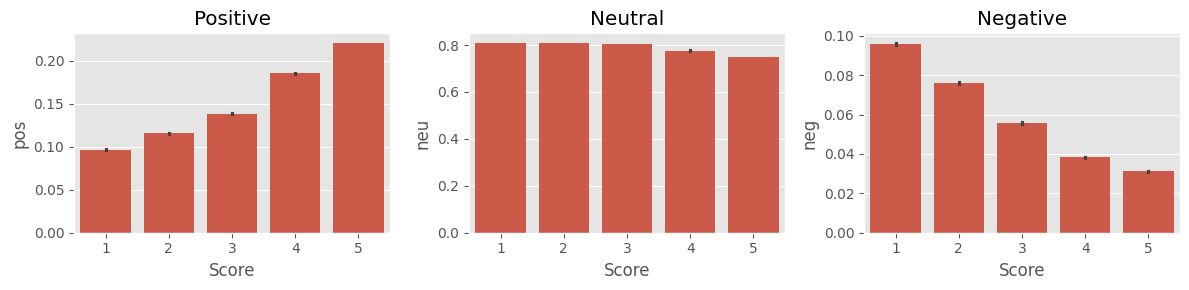

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

sns.barplot(data=vaders, x='Score', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='Score', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='Score', y='neg', ax=axs[2])

axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')

plt.tight_layout()
plt.show()

# Roberta Pretrained Model

1. Use a model trained of a large corpus of data.
2. Transformer model accounts for the words but also the context related to other words.

In [32]:
from transformers import AutoTokenizer   # Converts text into numerical tokens that the model can understand
from transformers import AutoModelForSequenceClassification   # Pretrained RoBERTa model that predicts sentiment (positive/neutral/negative)
from scipy.special import softmax   # Converts model output (logits) into probabilities

In [33]:
# Load pretrained RoBERTa sentiment analysis model and tokenizer from Hugging Face

MODEL = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [39]:
!conda install pytorch cpuonly -c pytorch -y

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - pytorch
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - cpuonly
    - pytorch


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.3.19  |       hca03da5_0         126 KB
    conda-26.1.1               |  py313hca03da5_0         1.2 MB
    cpuonly-2.0                |                0           2 KB  pytorch
    libtorch-2.7.0             |gpu_mps_hda230bc_200        28.4 MB
    nomkl-3.0                  |                0          10 KB
    openssl-3.5.5              |       ha0b305a_0         4.7 MB
    opentelemetry-api-1.38.0   |  py313hca03da5_0          99 KB
    pytorch-2.7.0              |gpu_mps_py313h91d4186_200        40.6 MB
    pytorch-mutex-1.0          |        

In [36]:
# VADER Results on example
print(example)
sia.polarity_scores(example)

I am very satisfied ,product is as advertised, I use it on cereal, with raw vinegar, and as a general sweetner.


{'neg': 0.0, 'neu': 0.846, 'pos': 0.154, 'compound': 0.4754}

In [38]:
# Run for ROBERTA Model
encoded_text=tokenizer(example,return_tensors='pt')
output=model(**encoded_text)
output

SequenceClassifierOutput(loss=None, logits=tensor([[-2.9546,  0.1082,  3.3415]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

In [40]:
encoded_text = tokenizer(example, return_tensors='pt')     # Convert input text into model-readable format (tokens → PyTorch tensors)
output = model(**encoded_text)         # Generate raw sentiment scores (logits) using pretrained RoBERTa model
scores = output[0][0].detach().numpy()      # Extract logits and convert them from tensor to NumPy array
scores = softmax(scores)      # Convert logits into normalized probabilities using softmax
scores_dict={
    'roberta_neg':scores[0],
    'roberta_neu':scores[1],
    'roberta_pos':scores[2]
}
scores_dict

{'roberta_neg': 0.0017705022,
 'roberta_neu': 0.037866905,
 'roberta_pos': 0.9603626}

In [41]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')     # Convert input text into model-readable format (tokens → PyTorch tensors)
    output = model(**encoded_text)         # Generate raw sentiment scores (logits) using pretrained RoBERTa model
    scores = output[0][0].detach().numpy()      # Extract logits and convert them from tensor to NumPy array
    scores = softmax(scores)      # Convert logits into normalized probabilities using softmax
    scores_dict={
        'roberta_neg':scores[0],
        'roberta_neu':scores[1],
        'roberta_pos':scores[2]
    }
    return scores_dict

Using a subset of 3000 rows to optimize performance, as deep learning models like RoBERTa are computationally expensive on large datasets

In [50]:
res = {}

# take only 3000 rows
df_sample = df.head(3000)

for i, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    try:
        text = row['Text']   # truncate to avoid errors
        myid = row['Id']
        
        # VADER sentiment
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        
        # RoBERTa sentiment
        roberta_result = polarity_scores_roberta(text)
        
        # Combine both results
        both = {**vader_result_rename, **roberta_result}
        
        # Store result using Id as key
        res[myid] = both

    except RuntimeError:
        print(f'Broke for id {myid}')


  0%|          | 0/3000 [00:00<?, ?it/s]

Broke for id 83
Broke for id 187
Broke for id 529
Broke for id 540
Broke for id 746
Broke for id 863
Broke for id 1053
Broke for id 1070
Broke for id 1156
Broke for id 1321
Broke for id 1375
Broke for id 1498
Broke for id 1575
Broke for id 1796
Broke for id 1826
Broke for id 2169
Broke for id 2248
Broke for id 2476
Broke for id 2492
Broke for id 2584
Broke for id 2610
Broke for id 2897
Broke for id 2898
Broke for id 2902
Broke for id 2928
Broke for id 2942
Broke for id 2944
Broke for id 2947
Broke for id 2948


In [51]:
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'Id'})
results_df = results_df.merge(df, how='left')

In [53]:
results_df.head()

,Id,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,0.009624,0.049980,0.940395,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,0.508986,0.452414,0.038600,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,0.003229,0.098068,0.898704,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,0.002295,0.090219,0.907486,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,0.001635,0.010302,0.988063,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


# Compare Scores between Models

In [55]:
results_df.columns

Index(['Id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'ProductId', 'UserId',
       'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator',
       'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

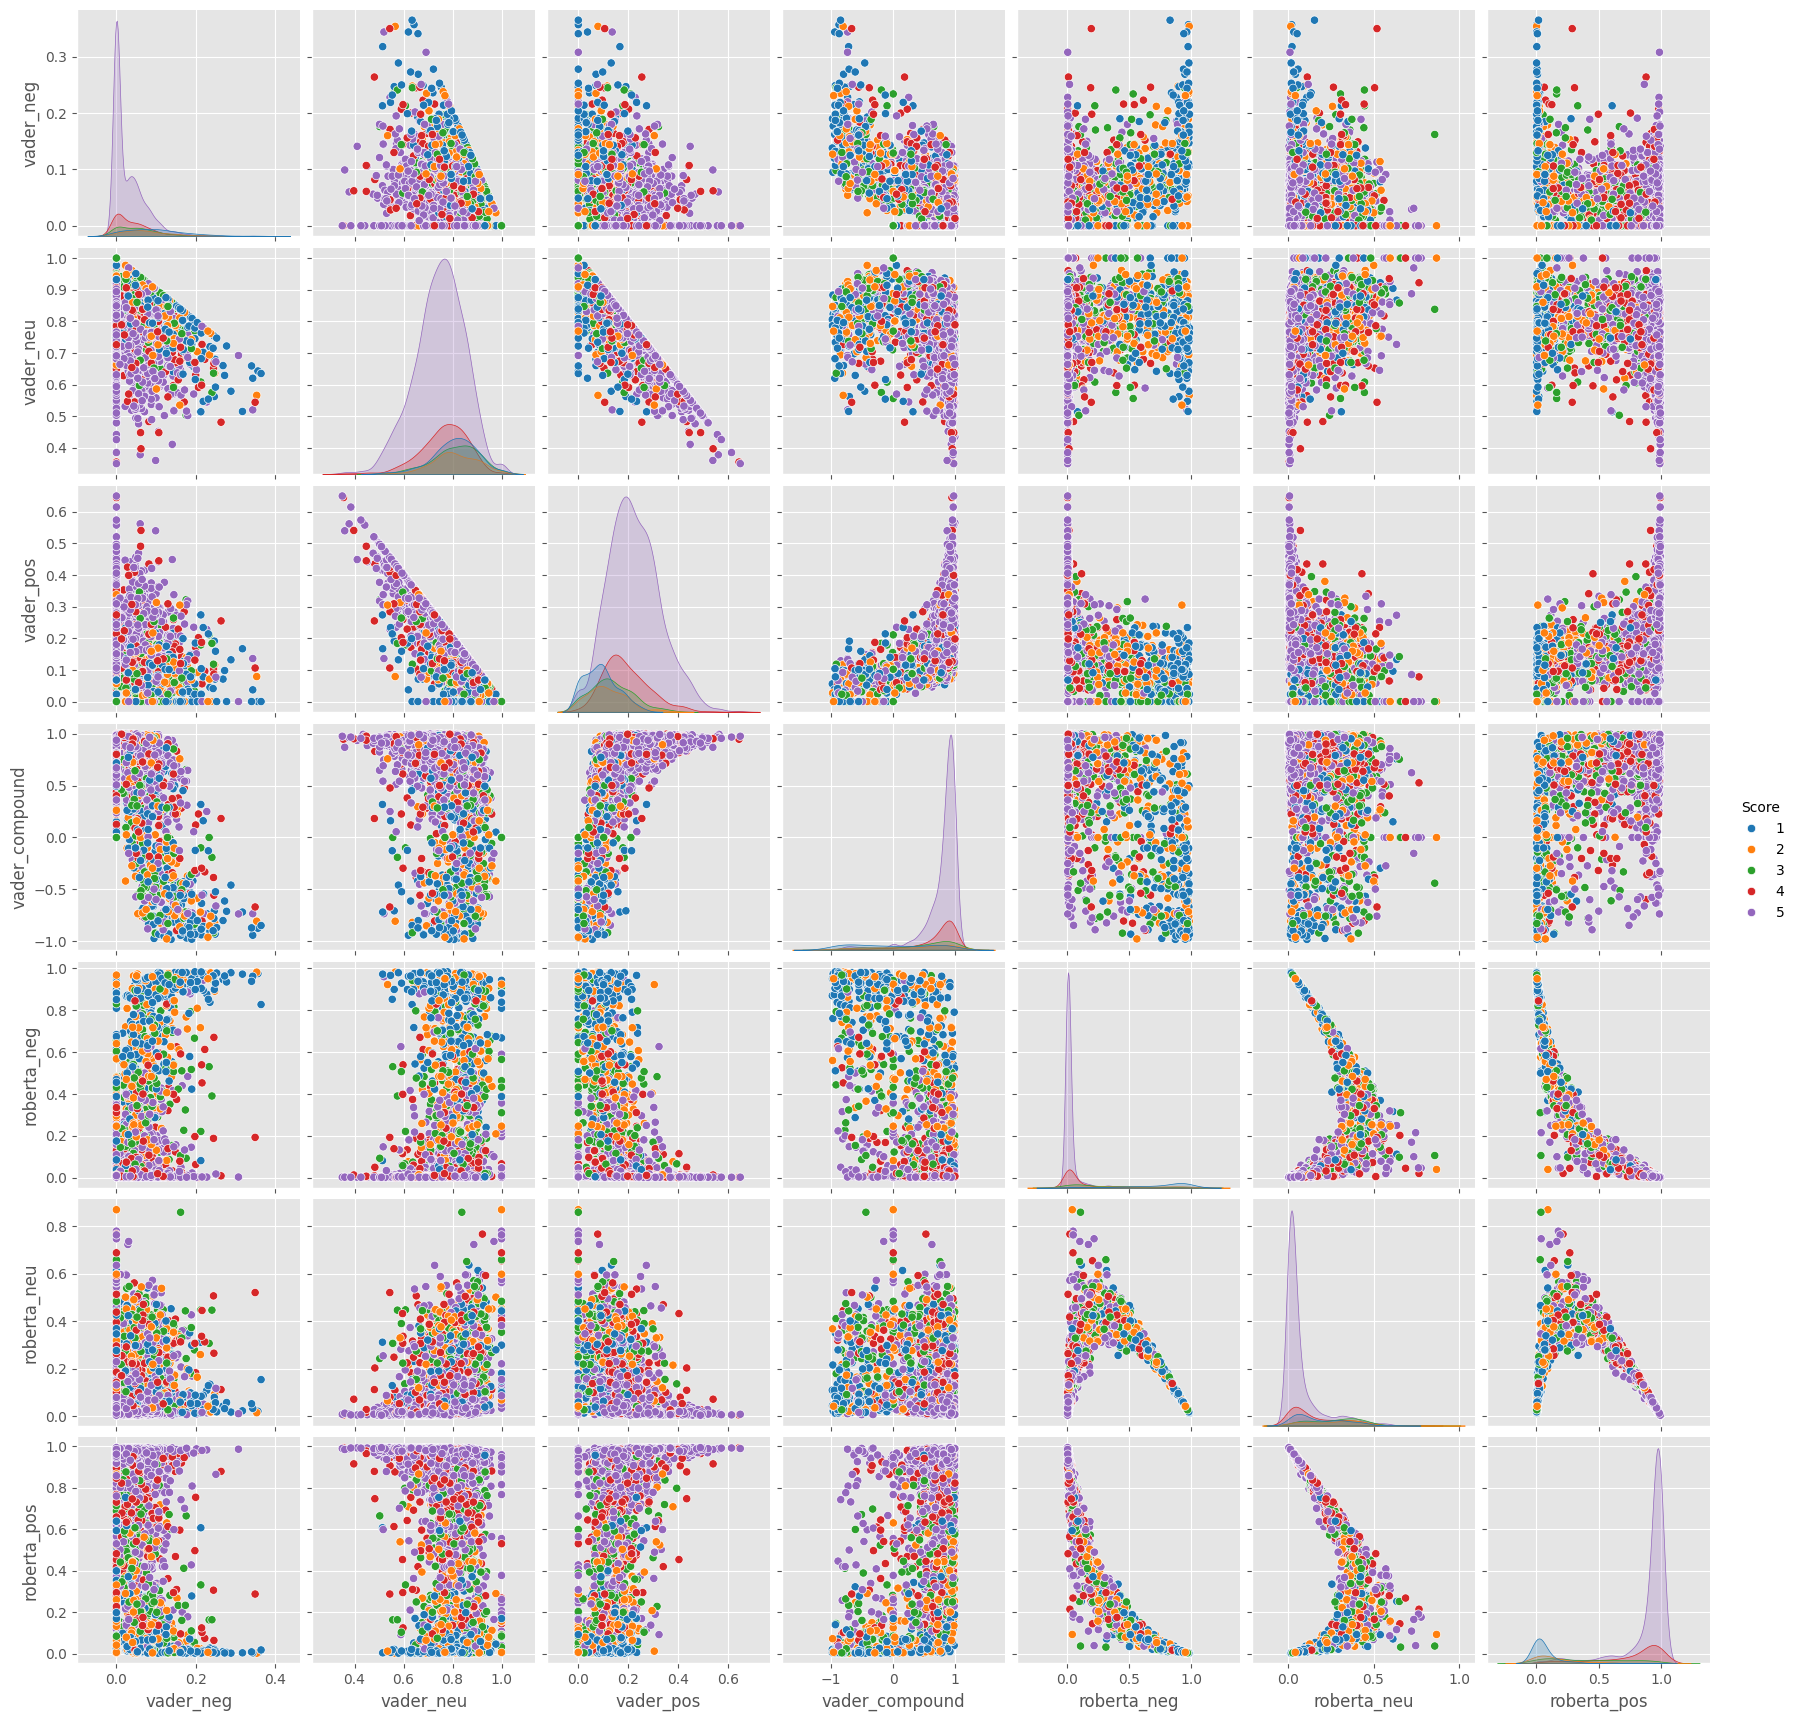

In [57]:
sns.pairplot(data=results_df,
            vars=['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos'],hue='Score',palette='tab10')
plt.show()

# Review Examples

Positive 1-Star By both the Models

In [58]:
# Finding a 1-star review that RoBERTa predicts as highly positive

results_df.query('Score == 1') \
    .sort_values('roberta_pos', ascending=False)['Text'].values[0]

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


'I got two Teas and one type of iced coffe and the rest were HOLIDAY COFFEES and APPLE CIDER!  Spicy Eggnog? Gingerbread? Bait and swtich.  The only redeeming factor - Amazon was great and issued me a refund.'

In [59]:
# Finding a 1-star review that VADER predicts as highly positive

results_df.query('Score == 1') \
    .sort_values('vader_pos', ascending=False)['Text'].values[0]

'So we cancelled the order.  It was cancelled without any problem.  That is a positive note...'

Negative 5-Star By both the Models

In [60]:
# Finding a 5-star review that RoBERTa predicts as highly negative

results_df.query('Score == 5') \
    .sort_values('roberta_neg', ascending=False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

In [61]:
# Finding a 5-star review that VADER predicts as highly negative

results_df.query('Score == 5') \
    .sort_values('vader_neg', ascending=False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'